# MovieLens latest-small 探索的データ分析

## 目的

MovieLens latest-smallの評価データと映画データを確認し、映画推薦システムの設計に必要な特徴や問題点を把握する。

## このNotebookで確認する内容

- ユーザー数、映画数、評価数
- 評価値の分布
- ユーザーごとの評価件数
- 映画ごとの評価件数
- 評価件数が少ない映画の割合
- ジャンルごとの映画数
- 評価データの疎らさ

> 現在は最初の作業単位として、データの読み込みと構造確認までを実装する。

## 1. ライブラリの読み込み

- `pathlib.Path`：ファイルやフォルダのパスを扱う
- `pandas`：CSVをDataFrameとして読み込み、表形式データを操作する
- `matplotlib.pyplot`：グラフを作成する（後のEDAで使用）

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

## 2. データファイルの場所を確認する

Notebookを`notebooks`フォルダから実行した場合と、プロジェクト直下から実行した場合の両方に対応して、プロジェクトの基準位置を決める。

`Path.exists()`は、指定したファイルが存在すれば`True`、存在しなければ`False`を返す。

In [2]:
# Notebookの現在の実行位置を確認する
current_dir = Path.cwd()

# notebooksフォルダで実行している場合は、1つ上をプロジェクトの基準位置にする
if current_dir.name == "notebooks":
    project_root = current_dir.parent
else:
    project_root = current_dir

data_dir = project_root / "data" / "raw" / "ml-latest-small"
ratings_path = data_dir / "ratings.csv"
movies_path = data_dir / "movies.csv"

print("現在の実行位置:", current_dir)
print("データフォルダ:", data_dir)
print("ratings.csvが存在するか:", ratings_path.exists())
print("movies.csvが存在するか:", movies_path.exists())

現在の実行位置: /Users/ma-ya/Free/movie-recommendation-system/notebooks
データフォルダ: /Users/ma-ya/Free/movie-recommendation-system/data/raw/ml-latest-small
ratings.csvが存在するか: True
movies.csvが存在するか: True


## 3. CSVをDataFrameとして読み込む

`pd.read_csv()`はCSVファイルのパスを入力として受け取り、表形式の`DataFrame`を返す。

データがまだ配置されていない場合は、期待する配置先を示すエラーで処理を止める。

In [3]:
# 必要なCSVが両方そろっていることを読み込み前に確認する
if not ratings_path.exists() or not movies_path.exists():
    raise FileNotFoundError(
        "MovieLensのCSVが見つかりません。"
        f"{data_dir} にratings.csvとmovies.csvを配置してください。"
    )

ratings = pd.read_csv(ratings_path)
movies = pd.read_csv(movies_path)

print("CSVの読み込みが完了しました。")

CSVの読み込みが完了しました。


## 4. 読み込み結果を確認する

- `DataFrame.shape`：`(行数, 列数)`を返す
- `DataFrame.head()`：先頭5行をDataFrameとして返す
- `display()`：DataFrameをNotebook上で表として表示する

In [4]:
print("ratingsの形:", ratings.shape)
print("moviesの形:", movies.shape)

print("ratingsの先頭5行")
display(ratings.head())

print("moviesの先頭5行")
display(movies.head())

ratingsの形: (100836, 4)
moviesの形: (9742, 3)
ratingsの先頭5行


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


moviesの先頭5行


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## この時点で確認すること

- `ratings.csv`と`movies.csv`がどちらも見つかるか
- `ratings`がおよそ100,836行・4列か
- `movies`がおよそ9,742行・3列か
- `userId`、`movieId`、`rating`、`timestamp`の意味を説明できるか
- `movieId`、`title`、`genres`の意味を説明できるか

次の作業単位では、欠損値、重複、データ型、評価値の範囲を確認する。

## データ構造の確認結果

- `ratings.csv`と`movies.csv`が存在し、想定した行数・列数で読み込めた。現時点では「ファイルが破損していない」と断定するのではなく、「想定した形式で読み込めた」と表現する。
- `userId`は、評価を行ったユーザーを識別する匿名IDである。
- `movieId`は映画を識別するIDであり、`ratings`と`movies`を結合する共通キーである。
- `rating`はユーザーが映画に付けた評価値である。先頭行では4.0や5.0を確認できたが、データ全体が想定範囲内かは、最小値・最大値・固有値を集計して確認する必要がある。
- `timestamp`は評価された日時を表し、過去の評価を学習用、未来の評価を評価用にする時系列分割で利用できる。
- `title`は映画名であり、主に推薦結果を人が理解できる形で表示するために利用する。映画の識別には`movieId`を使用する。
- `genres`は映画の大まかな特徴を表す。今回は主推薦方式には直接使用しないが、EDA、推薦結果の解釈、改善案の検討に利用できる。

### 現時点では未確認の内容

行数と列数が想定どおりでも、各セルの欠損値、重複、範囲外の評価値、`ratings`にしか存在しない`movieId`が含まれている可能性は残る。これらは次の分析で個別に確認する。

## 5. データ品質の確認

推薦システムの計算に使用する前に、必要な列、データ型、欠損値を確認する。この段階ではデータを修正せず、問題の有無を確認する。

### 5.1 必要な列の確認

必要な列名と実際の列名を集合として比較する。入力は2つの列名集合、出力は不足している列名の集合である。結果が空集合の`set()`なら不足はない。

In [5]:
# 推薦と評価に必要な列を定義する
required_ratings_columns = {"userId", "movieId", "rating", "timestamp"}
required_movies_columns = {"movieId", "title", "genres"}

# 必要な列のうち、実際のデータに存在しない列を調べる
missing_ratings_columns = required_ratings_columns - set(ratings.columns)
missing_movies_columns = required_movies_columns - set(movies.columns)

print("ratingsで不足している列:", missing_ratings_columns)
print("moviesで不足している列:", missing_movies_columns)

ratingsで不足している列: set()
moviesで不足している列: set()


### 5.2 データ型の確認

`DataFrame.dtypes`は、各列のデータ型をSeriesとして返す。ID、評価値、時刻が数値計算に使える型で読み込まれているか確認する。

In [6]:
print("ratingsのデータ型")
display(ratings.dtypes)

print("moviesのデータ型")
display(movies.dtypes)

ratingsのデータ型


userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object

moviesのデータ型


movieId     int64
title      object
genres     object
dtype: object

### 5.3 欠損値の確認

`DataFrame.isna()`は各セルが欠損なら`True`を返し、`sum()`は列ごとの`True`を合計する。入力はDataFrame、出力は列ごとの欠損値数を持つSeriesである。未評価のユーザーと映画の組み合わせは、ここでいう欠損値とは異なる。

In [7]:
# 列ごとの欠損値数を集計する
ratings_missing = ratings.isna().sum()
movies_missing = movies.isna().sum()

print("ratingsの欠損値数")
display(ratings_missing)

print("moviesの欠損値数")
display(movies_missing)

ratingsの欠損値数


userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

moviesの欠損値数


movieId    0
title      0
genres     0
dtype: int64

### 5.1〜5.3の確認結果

- `ratings`と`movies`に不足している列はなかった。
- `userId`、`movieId`、`timestamp`は整数型、`rating`は小数型として読み込まれていた。
- `title`と`genres`は文字列を扱う`object`型として読み込まれていた。
- `ratings`と`movies`のすべての列で、pandasが欠損値として認識するセルは0件だった。
- 必要な列、データ型、欠損値には問題が見つからなかったため、次に重複と評価値の妥当性を確認する。

### 5.4 重複の確認

重複を確認する基本形は`DataFrame.duplicated(subset=None, keep="first")`である。

- `subset`：重複判定に使う列を指定する。省略すると全列を使う
- `keep="first"`：最初の行を残し、2行目以降を`True`にする（初期値）
- `keep=False`：重複グループに含まれるすべての行を`True`にする
- 出力：各行が重複かを示す真偽値のSeries

`duplicated().sum()`で2行目以降の重複件数を数え、`keep=False`で該当グループ全体を抽出できる。今回は次の3種類を分けて確認する。

1. `ratings`の全列が同じ完全重複
2. `ratings`で`userId`と`movieId`が同じ組み合わせ
3. `movies`の完全重複と`movieId`の重複

同じユーザー・映画の評価が複数あると、評価行列の1つのマスに複数値が対応してしまう。`movies.movieId`が重複していると、結合時に評価行が増える可能性がある。

In [8]:
# ratingsで全列が同じ完全重複を数える
ratings_exact_duplicate_count = int(ratings.duplicated().sum())

# 同じユーザーと映画の組み合わせに含まれる全行を抽出する
user_movie_duplicate_mask = ratings.duplicated(
    subset=["userId", "movieId"],
    keep=False,
)
user_movie_duplicate_rows = ratings.loc[user_movie_duplicate_mask].sort_values(
    ["userId", "movieId", "timestamp"]
)
user_movie_duplicate_pair_count = (
    user_movie_duplicate_rows[["userId", "movieId"]]
    .drop_duplicates()
    .shape[0]
)

# moviesの完全重複と、識別キーmovieIdの重複を数える
movies_exact_duplicate_count = int(movies.duplicated().sum())
movie_id_duplicate_count = int(
    movies.duplicated(subset=["movieId"]).sum()
)

print("ratingsの完全重複行数:", ratings_exact_duplicate_count)
print("同じuserId・movieIdを持つ行数:", len(user_movie_duplicate_rows))
print("重複しているuserId・movieIdの組数:", user_movie_duplicate_pair_count)
print("moviesの完全重複行数:", movies_exact_duplicate_count)
print("moviesで重複しているmovieId数:", movie_id_duplicate_count)

# 重複が見つかった場合だけ、先頭10行を表示して内容を確認する
if not user_movie_duplicate_rows.empty:
    display(user_movie_duplicate_rows.head(10))

ratingsの完全重複行数: 0
同じuserId・movieIdを持つ行数: 0
重複しているuserId・movieIdの組数: 0
moviesの完全重複行数: 0
moviesで重複しているmovieId数: 0


#### 重複確認コードの読み方

- `ratings.loc[マスク]`：マスクが`True`の行だけを返す
- `sort_values([...])`：指定した列の順に行を並べる
- `drop_duplicates()`：同じ値を持つ重複行を1行にまとめる
- `shape[0]`：DataFrameの行数を返す
- `DataFrame.empty`：行が0件なら`True`を返す

重複が見つかった場合はすぐ削除せず、評価値と`timestamp`を見て原因と扱いを判断する。

### 5.5 評価値の妥当性

MovieLens latest-smallの`rating`は0.5〜5.0の0.5刻みを想定する。最小値と最大値だけでは途中の不正値を発見できないため、観測された評価値の種類と許可値に含まれない件数も確認する。

- `Series.min()`：列の最小値を返す
- `Series.max()`：列の最大値を返す
- `Series.unique()`：重複を除いた値をNumPy配列として返す
- `NumPy配列.tolist()`：NumPy配列を通常のPythonリストへ変換する
- `sorted()`：受け取った値を昇順のリストとして返す
- `Series.isin(値の集合)`：各値が集合に含まれるかを真偽値で返す
- `~`：`True`と`False`を反転し、許可値に含まれない行を抽出する

In [9]:
# MovieLensで許可される評価値を明示する
valid_rating_values = {
    0.5, 1.0, 1.5, 2.0, 2.5,
    3.0, 3.5, 4.0, 4.5, 5.0,
}

rating_min = ratings["rating"].min()
rating_max = ratings["rating"].max()
observed_rating_values = sorted(ratings["rating"].unique().tolist())

# 許可値に含まれない評価を抽出するマスクを作る
invalid_rating_mask = ~ratings["rating"].isin(valid_rating_values)
invalid_ratings = ratings.loc[invalid_rating_mask]

print("評価値の最小値:", rating_min)
print("評価値の最大値:", rating_max)
print("観測された評価値:", observed_rating_values)
print("許可値に含まれない評価の件数:", len(invalid_ratings))

# 不正値が見つかった場合だけ、先頭10行を表示する
if not invalid_ratings.empty:
    display(invalid_ratings.head(10))

評価値の最小値: 0.5
評価値の最大値: 5.0
観測された評価値: [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
許可値に含まれない評価の件数: 0


### 5.4〜5.5の確認結果

- `ratings`に全列が同じ完全重複はなかった。
- 同じ`userId`と`movieId`を持つ評価行はなく、各ユーザー・映画の組み合わせに評価は1件だった。
- `movies`に完全重複はなく、識別キーである`movieId`の重複もなかった。
- `rating`の最小値は0.5、最大値は5.0だった。
- 観測された評価値は0.5〜5.0の0.5刻みで、許可値に含まれない評価は0件だった。
- 重複による二重集計や範囲外評価の問題は見つからなかったため、現時点で削除・補正は行わない。

### 5.6 `movieId`の整合性

`ratings`に登場する映画が、すべて`movies`に登録されているか確認する。対応する映画がなければ、評価値はあってもタイトルやジャンルを取得できない。

確認には集合の差を使う。基本形は`集合A - 集合B`で、Aにだけ含まれる要素が返る。

- `set(Series)`：列の値を重複のない集合へ変換する
- `ratingsのID集合 - moviesのID集合`：映画情報が存在しない評価側のID
- `moviesのID集合 - ratingsのID集合`：映画情報はあるが評価が0件のID
- `Series.isin(値の集合)`：各値が集合に含まれるかを真偽値で返す

前者はデータ整合性の問題になる。後者は異常とは限らないが、評価を使う協調フィルタリングでは学習できない映画になる。

In [10]:
# ratingsとmoviesに登場する映画IDを、それぞれ集合にする
rated_movie_ids = set(ratings["movieId"])
master_movie_ids = set(movies["movieId"])

# 片方にだけ存在する映画IDを調べる
ratings_only_movie_ids = sorted(rated_movie_ids - master_movie_ids)
movies_without_ratings_ids = sorted(master_movie_ids - rated_movie_ids)

# 評価が0件の映画について、人が確認できる情報を取得する
movies_without_ratings = (
    movies.loc[
        movies["movieId"].isin(movies_without_ratings_ids),
        ["movieId", "title", "genres"],
    ]
    .sort_values("movieId")
)

print("ratingsにだけ存在するmovieId数:", len(ratings_only_movie_ids))
print("moviesにあるが評価0件の映画数:", len(movies_without_ratings_ids))

# 該当する映画がある場合だけ、先頭10件を表示する
if not movies_without_ratings.empty:
    display(movies_without_ratings.head(10))

ratingsにだけ存在するmovieId数: 0
moviesにあるが評価0件の映画数: 18


,movieId,title,genres
816,1076,"Innocents, The (1961)",Drama|Horror|Thriller
2211,2939,Niagara (1953),Drama|Thriller
2499,3338,For All Mankind (1989),Documentary
2587,3456,"Color of Paradise, The (Rang-e khoda) (1999)",Drama
3118,4194,I Know Where I'm Going! (1945),Drama|Romance|War
4037,5721,"Chosen, The (1981)",Drama
4506,6668,"Road Home, The (Wo de fu qin mu qin) (1999)",Drama|Romance
4598,6849,Scrooge (1970),Drama|Fantasy|Musical
4704,7020,Proof (1991),Comedy|Drama|Romance
5020,7792,"Parallax View, The (1974)",Thriller


### 5.7 `timestamp`の妥当性

`timestamp`を日時へ変換できるか確認し、評価期間を把握する。元の列は変更せず、確認用のSeriesを作る。

基本形は`pd.to_datetime(値, unit="s", utc=True, errors="coerce")`である。

- 入力：Unix時間を持つ`timestamp`列
- `unit="s"`：値の単位を秒として解釈する
- `utc=True`：UTCのタイムゾーン情報を付ける
- `errors="coerce"`：変換不能な値を欠損日時の`NaT`にする
- 出力：日時型のSeries

変換後に`isna().sum()`で`NaT`を数え、`min()`と`max()`で最古・最新の評価日時を確認する。時系列分割では、この日時を使って過去を学習用、未来を評価用にする。

In [11]:
# Unix時間をUTCの日時へ変換する。元のtimestamp列は変更しない
rating_datetimes = pd.to_datetime(
    ratings["timestamp"],
    unit="s",
    utc=True,
    errors="coerce",
)

invalid_timestamp_mask = rating_datetimes.isna()
invalid_timestamp_count = int(invalid_timestamp_mask.sum())
oldest_rating_datetime = rating_datetimes.min()
latest_rating_datetime = rating_datetimes.max()

print("日時へ変換できないtimestamp数:", invalid_timestamp_count)
print("最古の評価日時（UTC）:", oldest_rating_datetime)
print("最新の評価日時（UTC）:", latest_rating_datetime)

# 変換できない時刻が見つかった場合だけ、元データを表示する
if invalid_timestamp_count > 0:
    display(ratings.loc[invalid_timestamp_mask].head(10))

日時へ変換できないtimestamp数: 0
最古の評価日時（UTC）: 1996-03-29 18:36:55+00:00
最新の評価日時（UTC）: 2018-09-24 14:27:30+00:00


### 5.6〜5.7の確認結果

- `ratings`に登場するすべての`movieId`が`movies`にも存在し、評価と映画情報の対応に問題はなかった。
- `movies`には存在するが評価が0件の映画が18本あった。これはデータ不整合ではないが、評価情報だけを使う協調フィルタリングでは推薦スコアを計算できない映画になる。
- 日時へ変換できない`timestamp`は0件だった。
- 評価期間は1996年3月29日から2018年9月24日までだった（UTC）。
- `timestamp`を時系列の学習・評価データ分割に利用できると判断した。
- データ品質上の問題は見つからなかったため、この段階では行の削除や値の補正を行わない。

## 6. データの基本集計

データ品質に問題がないことを確認できたため、推薦システムが扱うデータの規模を把握する。ここでは次の5項目を集計する。

1. 評価を行ったユーザー数
2. 映画マスタに登録されている映画数
3. 1件以上評価された映画数
4. 評価の総数
5. 映画マスタにはあるが評価が0件の映画数

使用する基本形は次のとおりである。

- `Series.nunique()`：Series内の重複を除いた値の種類数を整数で返す
- `len(DataFrame)`：DataFrameの行数を整数で返す
- `set(Series)`：Seriesの値を重複のない集合へ変換する
- `len(集合A - 集合B)`：Aにだけ含まれる要素数を返す
- `pd.DataFrame(辞書)`：列名と値を持つ辞書を表形式のDataFrameへ変換する

映画数は、`movies`に登録された映画数と、`ratings`で実際に評価された映画数を分ける。評価がない映画は、評価情報だけを使う協調フィルタリングでは学習できないためである。

In [12]:
# 評価を行ったユーザー数
user_count = ratings["userId"].nunique()

# 映画マスタの映画数と、実際に評価された映画数
catalog_movie_count = movies["movieId"].nunique()
rated_movie_count = ratings["movieId"].nunique()

# ratingsの1行は1件の評価を表すため、行数を評価総数とする
rating_count = len(ratings)

# 映画マスタにだけ存在するmovieIdを使って、評価0件の映画数を求める
unrated_movie_count = len(
    set(movies["movieId"]) - set(ratings["movieId"])
)

# 結果を比較しやすい表にまとめる
basic_counts = pd.DataFrame(
    {
        "項目": [
            "ユーザー数",
            "映画マスタの映画数",
            "評価された映画数",
            "評価数",
            "評価0件の映画数",
        ],
        "件数": [
            user_count,
            catalog_movie_count,
            rated_movie_count,
            rating_count,
            unrated_movie_count,
        ],
    }
)

display(basic_counts)

,項目,件数
0,ユーザー数,610
1,映画マスタの映画数,9742
2,評価された映画数,9724
3,評価数,100836
4,評価0件の映画数,18


### 基本集計の結果

- 評価を行ったユーザーは610人だった。
- 映画マスタには9,742本が登録され、そのうち9,724本に1件以上の評価があった。
- 評価は合計100,836件だった。
- 評価0件の映画は18本で、映画マスタ全体の一部だった。
- 以降の評価分布や協調フィルタリングでは、主に評価履歴を持つ9,724本が対象になる。評価0件の映画を推薦するには、ジャンルなど評価以外の情報を使う方法が必要になる。

## 7. 評価値の分布

評価値ごとの件数と割合を確認し、ユーザーがどの評価を多く付けているか把握する。この結果は、定量評価で何点以上を「好みの映画」とするか決める根拠の1つになる。

- `Series.value_counts()`：値ごとの出現件数をSeriesとして返す
- `Series.value_counts(normalize=True)`：件数ではなく全体に占める比率を返す
- `Series.sort_index()`：評価値をインデックス順に並べる
- `Series.round(2)`：数値を小数第2位に丸める
- `pd.DataFrame(辞書)`：同じインデックスを持つSeriesを列としてまとめる

`normalize=True`の出力は0〜1の比率なので、100を掛けてパーセントに変換する。

In [13]:
# 評価値ごとの件数を、評価値の昇順で集計する
rating_counts = ratings["rating"].value_counts().sort_index()

# 評価値ごとの割合をパーセントに変換する
rating_percentages = (
    ratings["rating"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

# 件数と割合を1つの表にまとめる
rating_distribution = pd.DataFrame(
    {
        "件数": rating_counts,
        "割合（%）": rating_percentages,
    }
)
rating_distribution.index.name = "評価値"

display(rating_distribution)

,件数,割合（%）
評価値,,
0.5,1370,1.36
1.0,2811,2.79
1.5,1791,1.78
2.0,7551,7.49
2.5,5550,5.50
3.0,20047,19.88
3.5,13136,13.03
4.0,26818,26.60
4.5,8551,8.48


### 評価値分布の可視化

棒グラフを使うと、離散的な評価値ごとの件数を比較しやすい。

- `plt.subplots()`：グラフ全体の`Figure`と、描画領域の`Axes`を返す
- `Axes.bar(x, height)`：横軸の値と棒の高さを受け取り、棒グラフを描く
- `Axes.set_title()`、`set_xlabel()`、`set_ylabel()`：タイトルと軸名を設定する
- `plt.show()`：作成したグラフをNotebookへ表示する

実行環境による日本語フォントの違いを避け、GitHubでも表示を再現しやすくするため、グラフ内の文字は英語にする。

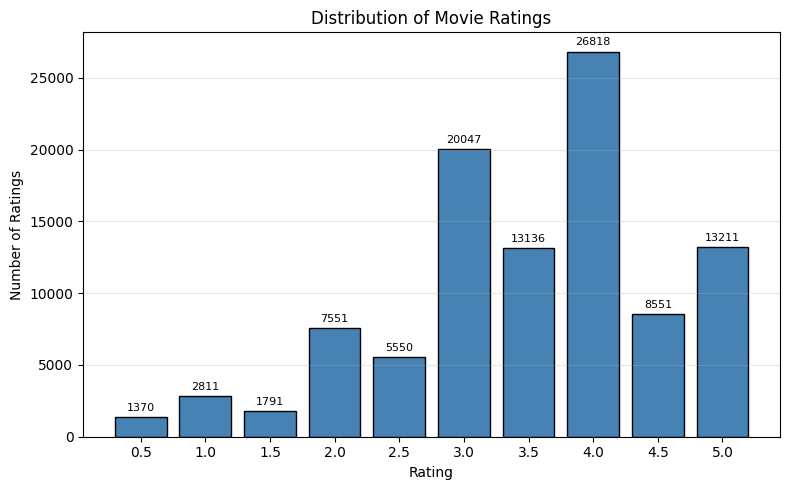

In [14]:
# 評価値を横軸、評価件数を縦軸にした棒グラフを作る
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    rating_counts.index.astype(str),
    rating_counts.values,
    color="steelblue",
    edgecolor="black",
)

ax.set_title("Distribution of Movie Ratings")
ax.set_xlabel("Rating")
ax.set_ylabel("Number of Ratings")
ax.grid(axis="y", alpha=0.3)
ax.bar_label(bars, padding=3, fontsize=8)

fig.tight_layout()
plt.show()

### 「好み」とする評価値の候補

推薦の定量評価では、評価値をそのまま使う方法に加え、一定以上の評価を「関連する映画」とする方法がある。今回は4.0以上を候補として件数と割合を確認する。

比較式`ratings["rating"] >= 4.0`は、条件を満たす行を`True`とする真偽値のSeriesを返す。`sum()`は該当件数、`mean()`は`True`の割合を返す。

In [15]:
# 評価用の「好み」とする閾値候補
positive_rating_threshold = 4.0
positive_rating_mask = ratings["rating"] >= positive_rating_threshold

positive_rating_count = int(positive_rating_mask.sum())
positive_rating_percentage = positive_rating_mask.mean() * 100
rating_mean = ratings["rating"].mean()
rating_median = ratings["rating"].median()

print(f"評価値の平均: {rating_mean:.2f}")
print(f"評価値の中央値: {rating_median:.1f}")
print(f"4.0以上の評価件数: {positive_rating_count:,}")
print(f"4.0以上の評価割合: {positive_rating_percentage:.2f}%")

評価値の平均: 3.50
評価値の中央値: 3.5
4.0以上の評価件数: 48,580
4.0以上の評価割合: 48.18%


### 評価値分布の確認結果

- 最も多い評価値は4.0で、26,818件、全体の26.60%だった。
- 評価値の平均は約3.50、中央値は3.5だった。
- 4.0以上の評価は48,580件で、全体の48.18%だった。
- 低評価より3.0以上の評価が多く、評価分布は一様ではなかった。
- 4.0以上は「明確に高い評価」と解釈しやすく、対象件数も十分にあるため、定量評価で好みを表す閾値の候補とする。
- 最終的な閾値は学習・評価データの分割方法を設計する際に固定し、モデルごとに変更しない。

## 8. ユーザーごとの評価傾向

ユーザーごとの評価件数と平均評価を集計し、評価履歴の量や採点傾向にどの程度の違いがあるか確認する。4.0以上の評価件数も数え、固定閾値で評価できるユーザーがどれくらいいるかを把握する。

- `DataFrame.assign()`：元のDataFrameを変更せず、指定した列を追加した新しいDataFrameを返す
- `DataFrame.groupby("userId")`：同じユーザーIDを持つ行をグループ化する
- `GroupBy.agg()`：グループごとに件数、平均、合計などを計算する
- `DataFrame.describe()`：件数、平均、標準偏差、最小値、四分位点、最大値を返す
- `Series.corr()`：2つの数値列のピアソン相関係数を返す

ここで計算するユーザー平均はEDA用である。推薦と定量評価では、データリークを避けるため学習データだけから改めて計算する。

In [16]:
# 4.0以上かを表す確認用の列を追加し、ユーザーごとに集計する
user_rating_stats = (
    ratings.assign(
        is_positive=ratings["rating"] >= positive_rating_threshold
    )
    .groupby("userId")
    .agg(
        rating_count=("rating", "count"),
        rating_mean=("rating", "mean"),
        positive_rating_count=("is_positive", "sum"),
    )
)

# ユーザー別統計の分布を要約する
user_rating_summary = user_rating_stats.describe().round(2)
rating_count_mean_correlation = user_rating_stats["rating_count"].corr(
    user_rating_stats["rating_mean"]
)

display(user_rating_summary)
print(f"評価件数と平均評価の相関係数: {rating_count_mean_correlation:.3f}")

,rating_count,rating_mean,positive_rating_count
count,610.00,610.00,610.00
mean,165.30,3.66,79.64
std,269.48,0.48,109.32
min,20.00,1.27,0.00
25%,35.00,3.36,21.00
50%,70.50,3.69,40.00
75%,168.00,4.00,91.75
max,2698.00,5.00,1227.00


評価件数と平均評価の相関係数: -0.199


### 平均評価が低い・高いユーザーの確認

平均評価の両端だけでなく評価件数も同時に見る。履歴が少ないユーザーの平均は、少数の評価によって大きく変化しやすいためである。

`sort_values(列名)`は指定した列の昇順、`ascending=False`を指定すると降順に並べる。`head(5)`で先頭5行を取得する。

In [17]:
lowest_mean_users = (
    user_rating_stats
    .sort_values("rating_mean")
    .head(5)
    .round(2)
)
highest_mean_users = (
    user_rating_stats
    .sort_values("rating_mean", ascending=False)
    .head(5)
    .round(2)
)

print("平均評価が低いユーザー")
display(lowest_mean_users)

print("平均評価が高いユーザー")
display(highest_mean_users)

平均評価が低いユーザー


,rating_count,rating_mean,positive_rating_count
userId,,,
442,20,1.27,0
139,194,2.14,13
508,24,2.15,4
153,179,2.22,35
567,385,2.25,41


平均評価が高いユーザー


,rating_count,rating_mean,positive_rating_count
userId,,,
53,20,5.00,20
251,23,4.87,22
515,26,4.85,26
25,26,4.81,26
30,34,4.74,31


### ユーザー別統計の分布

評価件数と平均評価をそれぞれヒストグラムで確認する。`Axes.hist(値, bins=...)`は数値を区間に分け、各区間に含まれる件数を棒として描く。

評価件数には非常に大きな値を持つユーザーがいるため、縦軸を対数表示にして少数の区間も見えるようにする。グラフ内の文字は環境依存の日本語フォントを避けるため英語にする。

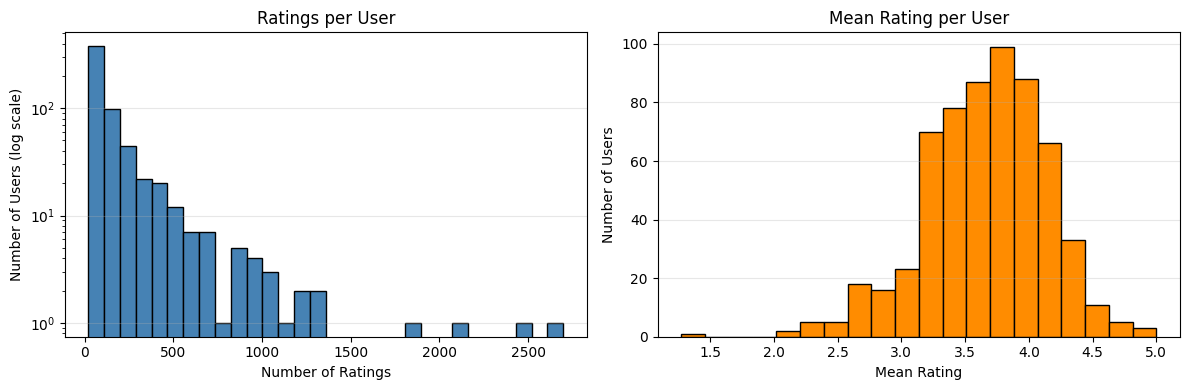

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ユーザーごとの評価件数分布
axes[0].hist(
    user_rating_stats["rating_count"],
    bins=30,
    color="steelblue",
    edgecolor="black",
)
axes[0].set_title("Ratings per User")
axes[0].set_xlabel("Number of Ratings")
axes[0].set_ylabel("Number of Users (log scale)")
axes[0].set_yscale("log")
axes[0].grid(axis="y", alpha=0.3)

# ユーザーごとの平均評価分布
axes[1].hist(
    user_rating_stats["rating_mean"],
    bins=20,
    color="darkorange",
    edgecolor="black",
)
axes[1].set_title("Mean Rating per User")
axes[1].set_xlabel("Mean Rating")
axes[1].set_ylabel("Number of Users")
axes[1].grid(axis="y", alpha=0.3)

fig.tight_layout()
plt.show()

### 評価件数と平均評価の関係

散布図で、履歴の多さと平均評価の関係を確認する。`Axes.scatter(x, y)`はxとyの組を点として描く。評価件数の範囲が広いため、`set_xscale("log")`で横軸を対数表示にする。破線は全評価の平均3.50を表す。

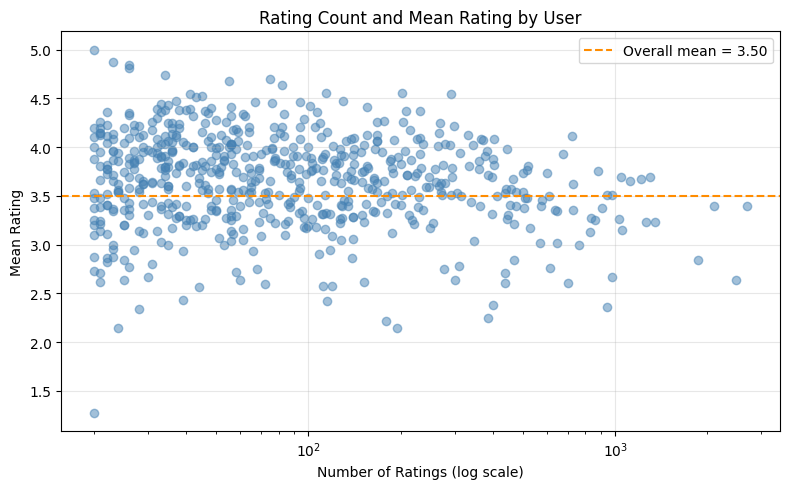

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    user_rating_stats["rating_count"],
    user_rating_stats["rating_mean"],
    alpha=0.5,
    color="steelblue",
)
ax.axhline(
    rating_mean,
    color="darkorange",
    linestyle="--",
    label=f"Overall mean = {rating_mean:.2f}",
)
ax.set_xscale("log")
ax.set_title("Rating Count and Mean Rating by User")
ax.set_xlabel("Number of Ratings (log scale)")
ax.set_ylabel("Mean Rating")
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()

### ユーザー別評価傾向の確認結果

- ユーザーごとの評価件数は最小20件、中央値70.5件、最大2,698件で、一部のユーザーが非常に多く評価していた。
- ユーザー平均は最小1.27、中央値3.69、最大5.00で、採点の厳しさに大きな違いがあった。
- 平均評価が3.0未満のユーザーは49人、4.0以上のユーザーは153人だった。
- 評価件数と平均評価の相関係数は-0.199で、弱い負の関係はあるものの、強い関係ではなかった。
- 4.0以上の評価を1件も持たないユーザーは1人、5件未満のユーザーは7人だった。全データ上では固定閾値による評価対象を多く確保できるが、時系列分割後に再確認が必要である。
- ユーザーごとの平均評価に幅があるため、協調フィルタリングでは学習データからユーザー平均を求め、平均との差を使う平均中心化が有効な候補になる。
- ユーザー平均からの差を関連判定に使う場合も、全データの平均は利用せず、時系列分割後の学習データだけから再計算する。